# ERA5 three ways: pvlib, Arraylake and ECMWF ARCO, vs. an IFS forecast for Madrid

This notebook ([#109](https://github.com/williamhobbs/hefty/issues/109)) uses ERA5 reanalysis as a reference for a hefty day-ahead IFS forecast at a hypothetical solar plant near Madrid, Spain. It fetches the same ERA5 point time series in three ways and times each one:

1. **pvlib**: [`pvlib.iotools.get_era5`](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_era5.html) queries the CDS [ERA5 time-series](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries) API. You submit a job, wait in the queue, then download a CSV.
2. **Arraylake**: the free [`earthmover-public/era5`](https://app.earthmover.io/marketplace/6a19bcfe9aa6e97720a2fad2) Icechunk repo, group `single/temporal`, which is chunked for time series. It is updated quarterly and currently runs to 2026-03-31.
3. **ECMWF ARCO**: ECMWF's [Analysis-ready ERA5 single levels](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=analysis_ready_data) Zarr store, read from the `geoChunked` copy, which is chunked for time series. This is a beta service.

All three serve the same 0.25° ERA5 grid, so they should return identical values for the nearest grid cell. The comparison period is March 2026, which falls inside the free Arraylake product.

### Credentials
Put these in a `.env` file at the repository root. `.env` is already listed in `.gitignore`.
```
PRIVATE_CDSAPI_KEY=<your CDS personal access token>   # pvlib and ECMWF ARCO
ARRAYLAKE_TOKEN=<your Arraylake API token>            # Arraylake
```
You need to accept the ERA5 licence on the CDS website once before the CDS key will work.

### Extra dependencies
hefty does not depend on any of these packages, so install only the ones for the sources you want to use. Each cell below covers one source. After installing, restart the kernel.

**dynamical.org** (IFS forecast via hefty) and `python-dotenv` (to read `.env`):

In [ ]:
%pip install -q dynamical_catalog cartopy python-dotenv

**pvlib**: no extra packages needed, because `pvlib.iotools.get_era5` ships with pvlib, which hefty already depends on.

**Arraylake** (Icechunk repo, PCodec-compressed Zarr v3):

In [ ]:
%pip install -q arraylake icechunk xarray zarr "numcodecs[pcodec]"

**ECMWF ARCO** (Zarr v2 over HTTPS, read with obstore as ECMWF recommends):

In [ ]:
%pip install -q obstore xarray zarr

In [4]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import xarray as xr
from dotenv import find_dotenv, load_dotenv

from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast

warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv(find_dotenv(usecwd=True));

## Site and period
The site is a hypothetical single-axis tracking plant just north of Madrid. The nearest ERA5 grid cell is 40.5°N, 3.75°W.

In [5]:
latitude, longitude = 40.42, -3.70  # Madrid, Spain

plant = dict(
    latitude=latitude,
    longitude=longitude,
    mount_type='single-axis',
    gcr=0.35,
    nameplate_dc=120,  # MW
    nameplate_ac=100,  # MW
    dc_loss_fraction=0.1,
    gamma_pdc=-0.003,
    shade_loss_model='non-linear_simple',
    backtrack=True,
    max_tracker_angle=55,
)

start, end = '2026-03-01', '2026-03-31'  # comparison month, inside the free Arraylake product
year_start = '2025-04-01'                # 1-year window for the timing benchmark

## ERA5 fetchers
Each fetcher returns hourly `ghi` (W/m²), `temp_air` (°C) and `wind_speed` (m/s, at 10 m) for the nearest grid cell, using pvlib's conventions.

ERA5 radiation is accumulated over the hour **ending** at the timestamp. The `to_pvlib` helper converts J/m² to W/m² and shifts the index back 30 minutes to the interval centre, which matches the timestamps hefty uses for forecasts.

In [6]:
def to_pvlib(df):
    """ERA5 short names (ssrd, t2m, u10, v10) -> pvlib names/units, interval-centred UTC index."""
    out = pd.DataFrame(index=pd.DatetimeIndex(df.index))
    out['ghi'] = df['ssrd'] / 3600
    out['temp_air'] = df['t2m'] - 273.15
    out['wind_speed'] = np.hypot(df['u10'], df['v10'])
    if out.index.tz is None:
        out.index = out.index.tz_localize('UTC')
    out.index = out.index - pd.Timedelta('30min')
    return out.astype('float64')

ERA5_VARS = ['ssrd', 't2m', 'u10', 'v10']
# the CDS time-series API only accepts long names, but returns short-name columns
ERA5_LONG_NAMES = ['surface_solar_radiation_downwards', '2m_temperature',
                   '10m_u_component_of_wind', '10m_v_component_of_wind']

### 1. pvlib (CDS time-series API)

In [7]:
def era5_pvlib(start, end):
    df, meta = pvlib.iotools.get_era5(
        latitude, longitude, start, end, ERA5_LONG_NAMES,
        api_key=os.environ['PRIVATE_CDSAPI_KEY'],
        map_variables=False, timeout=600)
    return to_pvlib(df)

### 2. Arraylake (`earthmover-public/era5`, `single/temporal`)
Longitudes run from 0 to 360 and latitudes are descending.

In [8]:
def era5_arraylake(start, end):
    from arraylake import Client
    repo = Client(token=os.environ['ARRAYLAKE_TOKEN']).get_repo('earthmover-public/era5')
    session = repo.readonly_session(branch='main')
    ds = xr.open_zarr(session.store, group='single/temporal', zarr_format=3, chunks=None)
    pt = (ds[ERA5_VARS]
          .sel(latitude=latitude, longitude=longitude % 360, method='nearest')
          .sel(valid_time=slice(start, f'{end} 23:00')))
    return to_pvlib(pt.load().to_dataframe()[ERA5_VARS])

### 3. ECMWF ARCO (`geoChunked`)
The store uses Zarr v2 with consolidated metadata and requires the CDS key as a Bearer token. Longitudes run from -180 to 180 and latitudes are ascending.

In [9]:
ECMWF_ARCO_URL = ('https://arco.datastores.ecmwf.int/cadl-arco-geo-002/arco/'
                  'reanalysis_era5_single_levels/sfc/geoChunked.zarr')

def era5_ecmwf(start, end):
    from obstore.store import HTTPStore
    from zarr.storage import ObjectStore
    headers = {'Authorization': f"Bearer {os.environ['PRIVATE_CDSAPI_KEY']}"}
    store = ObjectStore(HTTPStore.from_url(ECMWF_ARCO_URL, client_options={'default_headers': headers}),
                        read_only=True)
    ds = xr.open_zarr(store, consolidated=True, zarr_format=2, chunks=None)
    pt = (ds[ERA5_VARS]
          .sel(latitude=latitude, longitude=longitude, method='nearest')
          .sel(time=slice(start, f'{end} 23:00')))
    return to_pvlib(pt.load().to_dataframe()[ERA5_VARS])

## Timing
Each method fetches the same 4 variables for one month and for one year. Every call is cold: opening the store or submitting the CDS request is counted in the time. Results depend heavily on where you run the notebook. Arraylake is hosted in AWS `us-east-1` and ECMWF ARCO is hosted in Europe. pvlib timings also depend on the CDS queue.

In [10]:
fetchers = {'pvlib': era5_pvlib, 'arraylake': era5_arraylake, 'ecmwf': era5_ecmwf}
windows = {'1 month': (start, end), '1 year': (year_start, end)}

era5, rows = {}, []
for method, fetch in fetchers.items():
    for window, (t0, t1) in windows.items():
        tic = time.perf_counter()
        df = fetch(t0, t1)
        elapsed = time.perf_counter() - tic
        rows.append(dict(method=method, window=window, seconds=elapsed, hours=len(df)))
        print(f'{method:>9} {window:>7}: {elapsed:6.1f} s, {len(df)} hours')
        if window == '1 month':
            era5[method] = df

timing = pd.DataFrame(rows).pivot(index='method', columns='window', values='seconds')
timing.round(1)

    pvlib 1 month:   16.0 s, 744 hours


    pvlib  1 year:   19.7 s, 8760 hours


arraylake 1 month:   25.3 s, 744 hours


arraylake  1 year:   29.4 s, 8760 hours


    ecmwf 1 month:    3.9 s, 744 hours


    ecmwf  1 year:    2.6 s, 8760 hours


window,1 month,1 year
method,,
arraylake,25.3,29.4
ecmwf,3.9,2.6
pvlib,16.0,19.7


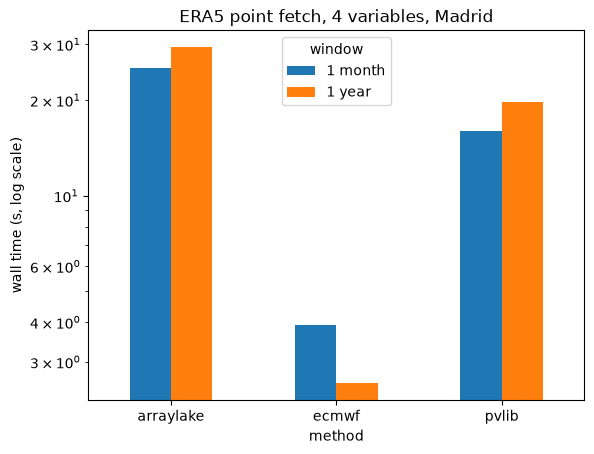

In [11]:
ax = timing.plot.bar(rot=0, logy=True)
ax.set_ylabel('wall time (s, log scale)')
ax.set_title('ERA5 point fetch, 4 variables, Madrid')
plt.show()

## Cross-check: are the three sources identical?
They should match. Each one is a lossless copy of the same ERA5 GRIB data, and pvlib's CSV uses rounded decimals.

In [12]:
diffs = pd.DataFrame({
    f'{a} - {b}': (era5[a] - era5[b]).abs().max()
    for a, b in [('arraylake', 'ecmwf'), ('arraylake', 'pvlib'), ('ecmwf', 'pvlib')]
})
diffs  # max absolute difference per variable

,arraylake - ecmwf,arraylake - pvlib,ecmwf - pvlib
ghi,0.0,3.038194e-05,3.038194e-05
temp_air,0.0,2.114258e-05,2.114258e-05
wind_speed,0.0,4.529972e-07,4.529972e-07


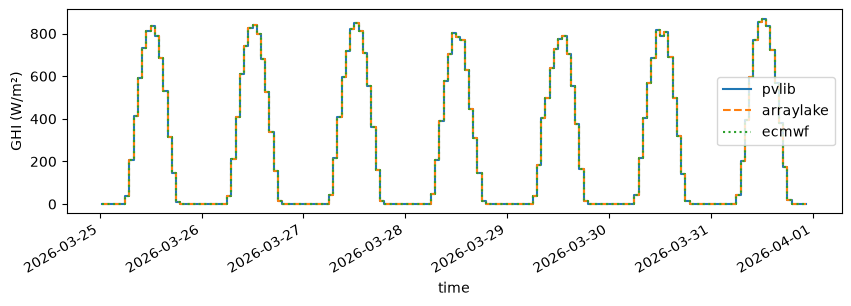

In [13]:
fig, ax = plt.subplots(figsize=(10, 3))
for (method, df), ls in zip(era5.items(), ['-', '--', ':']):
    df['ghi']['2026-03-25':].plot(ax=ax, ls=ls, label=method, drawstyle='steps-mid')
ax.set_ylabel('GHI (W/m²)')
ax.legend()
plt.show()

## Day-ahead IFS forecast from dynamical.org
This uses hefty's IFS forecast from dynamical (see [dynamical_example.ipynb](dynamical_example.ipynb)). Each run is initialized at 00Z, and the forecast covers the next calendar day, from 24 to 48 hours of lead time. Each dynamical call takes about 45 s no matter how long the run is, so the loop below covers the last week of March. Extend `init_dates` to include the whole month if you like.

In [14]:
init_dates = pd.date_range('2026-03-24', '2026-03-30', freq='1D')

fcast = pd.concat([
    get_solar_forecast(
        latitude=latitude, longitude=longitude, init_date=d,
        run_length=24, lead_time_to_start=24,
        model='ifs', attempts=3, priority='dynamical')
    for d in init_dates
])
fcast.head()

,point,temp_air,wind_speed,wind_direction,lead_time,ghi_csi,ghi,dni,dhi,ghi_clear
valid_time,,,,,,,,,,
2026-03-25 00:30:00+00:00,0,8.036458,0.171241,17.526163,24.5,0.0,0.0,0.0,0.0,NaN
2026-03-25 01:30:00+00:00,0,7.484375,0.328232,29.189575,25.5,0.0,0.0,0.0,0.0,NaN
2026-03-25 02:30:00+00:00,0,6.932292,0.485224,40.852985,26.5,0.0,0.0,0.0,0.0,NaN
2026-03-25 03:30:00+00:00,0,6.380208,0.553010,44.436066,27.5,0.0,0.0,0.0,0.0,NaN
2026-03-25 04:30:00+00:00,0,5.828125,0.531592,39.938812,28.5,0.0,0.0,0.0,0.0,NaN


## GHI: forecast vs ERA5

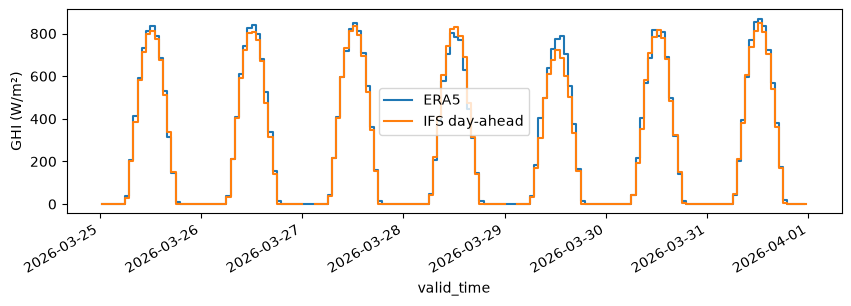

Daytime GHI  MBE:  -12.2 W/m²   MAE:   21.4 W/m²   RMSE:   29.1 W/m²


In [15]:
ref = era5['arraylake'].reindex(fcast.index)

fig, ax = plt.subplots(figsize=(10, 3))
ref['ghi'].plot(ax=ax, drawstyle='steps-mid', label='ERA5')
fcast['ghi'].plot(ax=ax, drawstyle='steps-mid', label='IFS day-ahead')
ax.set_ylabel('GHI (W/m²)')
ax.legend()
plt.show()

day = ref['ghi'] > 0
err = fcast['ghi'][day] - ref['ghi'][day]
print(f'Daytime GHI  MBE: {err.mean():6.1f} W/m²   MAE: {err.abs().mean():6.1f} W/m²   '
      f'RMSE: {np.sqrt((err**2).mean()):6.1f} W/m²')

## PV power: forecast vs ERA5
ERA5 provides only GHI. To get DNI and DHI, we use the Erbs decomposition, computed at the interval centre, as hefty does for forecasts by default. The ERA5 albedo is set to 0.2, the same value used for the forecast. Note that ERA5 wind speed is at 10 m.

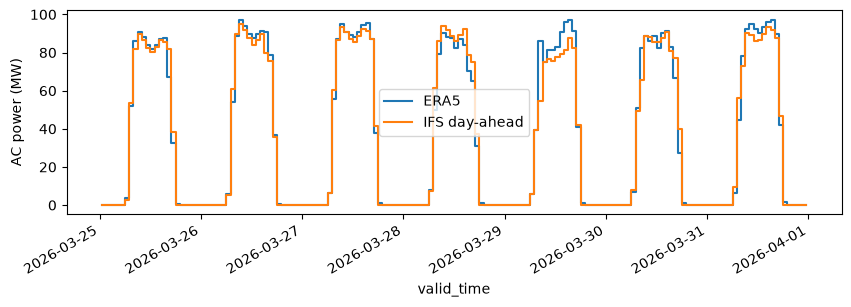

ERA5             6128.0
IFS day-ahead    6059.0
Forecast energy error: -1.1 %


In [16]:
def add_decomposition(df):
    df = df.copy()
    sp = pvlib.solarposition.get_solarposition(df.index, latitude, longitude)
    erbs = pvlib.irradiance.erbs(df['ghi'], sp['zenith'], df.index)
    df['dni'], df['dhi'] = erbs['dni'], erbs['dhi']
    return df

era5_resource = add_decomposition(ref)
era5_resource['albedo'] = 0.2
fcast_resource = fcast.copy()
fcast_resource['albedo'] = 0.2

power = pd.DataFrame({
    'ERA5': model_pv_power(resource_data=era5_resource, **plant)[0],
    'IFS day-ahead': model_pv_power(resource_data=fcast_resource, **plant)[0],
})

ax = power.plot(figsize=(10, 3), drawstyle='steps-mid')
ax.set_ylabel('AC power (MW)')
plt.show()

energy = power.sum()  # MWh, hourly data
print(energy.round(0).to_string())
print(f'Forecast energy error: {100 * (energy.iloc[1] / energy.iloc[0] - 1):.1f} %')

-----
_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/_

_Contains modified Copernicus Climate Change Service information 2026 (ERA5, Hersbach et al., 2023, doi:10.24381/cds.adbb2d47). Neither the European Commission nor ECMWF is responsible for any use that may be made of the Copernicus information or data it contains._